In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# 1. Load and Prepare Data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')
X = df.drop(['customer_id', 'default'], axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 3. Predict Probabilities and Calculate Expected Loss
y_probs = model.predict_proba(X_test)[:, 1]
lgd = 0.90  # 1 - 0.10 recovery rate
expected_losses = y_probs * X_test['loan_amt_outstanding'] * lgd

# Example Usage:
# Predict for a borrower with high debt and low fico
el = predict_expected_loss(5, 5000, 20000, 30000, 1, 550)
print(f"Expected Loss for high-risk borrower: ${el}")


Expected Loss for high-risk borrower: $4500.0


C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


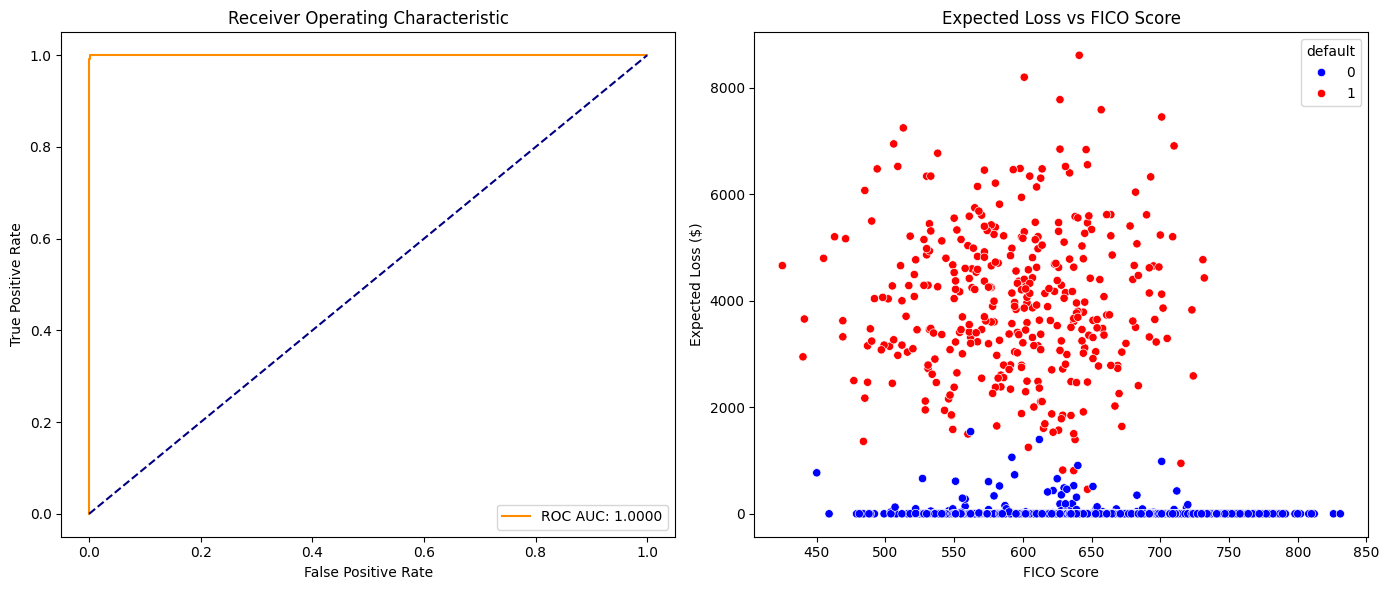

In [8]:
# 4. Create Visualizations
plt.figure(figsize=(14, 6))

# Plot A: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC AUC: {auc(fpr, tpr):.4f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# Plot B: Expected Loss vs FICO
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_test['fico_score'], y=expected_losses, hue=y_test, palette={0:'blue', 1:'red'})
plt.title('Expected Loss vs FICO Score')
plt.xlabel('FICO Score')
plt.ylabel('Expected Loss ($)')

plt.tight_layout()
plt.savefig('loan_risk_viz.png')